# Phase 2 → Lesson 2 → Model Evaluation
Training a model is easy. But how do you know if it's actually good? You need numbers that measure performance. In Linear Regression we use 3 metrics:

###Metric 1 — MAE (Mean Absolute Error)
first calculate error then abs then their mean
```
# Actual vs Predicted
actual    = [90, 75, 60]
predicted = [85, 78, 65]

# Errors
errors = [|90-85|, |75-78|, |60-65|]
       = [5, 3, 5]

# MAE = average of errors
MAE = (5 + 3 + 5) / 3 = 4.33
```
MAE = 4.33 means on average your prediction is off by 4.33 points. Simple and intuitive.

###Metric 2 — MSE (Mean Squared Error)

Same as MAE but squares the errors first
```
errors  = [5, 3, 5]
squared = [25, 9, 25]
MSE     = (25 + 9 + 25) / 3 = 19.67
```
Squaring punishes big errors more. A prediction off by 10 is penalized 4x more than one off by 5. Used in gradient descent — which you already coded!

###Metric 3 — R² Score (The Most Important One)

Measures how well your model explains the data

***R² = 1.0  → perfect model, explains everything***

***R² = 0.8  → model explains 80% of the pattern***

***R² = 0.65  → model explains 65% of the pattern of the data***

***R² = 0.0  → model is no better than guessing the mean***

***R² < 0    → model is worse than just guessing!***

In real projects, R² above 0.85 is generally considered a good model. This is the number you'll report most often.

### RMSE
root of mse

One Important Observation

Your RMSE for Salary model is 1007 — that sounds big but it's
actually good! Here's why:

Salaries range from 30,000 to 90,000
RMSE = 1,007

Error % = 1007/60000 = 1.7% error

Always interpret RMSE relative to your data range — not as an absolute number.



Practice — SET
Add this to your existing Hours vs Score model:

task 1: Calculate and print MAE, MSE, RMSE and R² for your model.

task 2: What does your R² score tell you about the model quality?



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {'Hours':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Score':  [35, 45, 50, 60, 65, 75, 80, 85, 90, 95]}

df = pd.DataFrame(data)
print(f'\nreal dataset\n:{df}')

x_train,x_test,y_train,y_test=train_test_split(df['Hours'],df['Score'],test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(x_train.values.reshape(-1,1),y_train)

y_pred=model.predict(x_test.values.reshape(-1,1))

print(f'\nActual values : {list(y_test)}')
print(f'\nPredicted values: \n{y_pred}')
print(f'\ncpomplete data set prediction\n')
pred=model.predict(df['Hours'].values.reshape(-1,1))
df['Predictions']=pred
print(df)

#lets test for an unseen value that is 12 hours first we add it
df.loc[10,'Hours']=12

val=df.loc[10,'Hours']

# now predict it
pred=model.predict(val.reshape(-1,1))

df.loc[10,'Predictions']=pred

print(df)
print(f'\nMAE: {mean_absolute_error(y_test,y_pred):.2f}')# average error in points
print(f'\nMSE: {mean_squared_error(y_test,y_pred):.2f}')# squared error
rMSE=np.sqrt(mean_squared_error(y_test,y_pred))# root of MSE — easier to interpret
print(f'\nRMSE : {rMSE:.2f}')
print(f'\nR2 Score: {r2_score(y_test,y_pred):.2f}')# how well model fits  ,If it is one the model explain and fit accurately and perfectly


real dataset
:   Hours  Score
0      1     35
1      2     45
2      3     50
3      4     60
4      5     65
5      6     75
6      7     80
7      8     85
8      9     90
9     10     95

Actual values : [90, 45]

Predicted values: 
[91.81034483 44.43965517]

cpomplete data set prediction

   Hours  Score  Predictions
0      1     35    37.672414
1      2     45    44.439655
2      3     50    51.206897
3      4     60    57.974138
4      5     65    64.741379
5      6     75    71.508621
6      7     80    78.275862
7      8     85    85.043103
8      9     90    91.810345
9     10     95    98.577586
    Hours  Score  Predictions
0     1.0   35.0    37.672414
1     2.0   45.0    44.439655
2     3.0   50.0    51.206897
3     4.0   60.0    57.974138
4     5.0   65.0    64.741379
5     6.0   75.0    71.508621
6     7.0   80.0    78.275862
7     8.0   85.0    85.043103
8     9.0   90.0    91.810345
9    10.0   95.0    98.577586
10   12.0    NaN   112.112069

MAE: 1.19

MSE: 1.80

RMS

task 3: Create this new dataset and build a complete Linear

```
Regression model with evaluation:
pythondata = {'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Salary':     [30000, 35000, 40000, 45000, 52000,
                       60000, 65000, 72000, 80000, 90000]}
```
Define X and y

Split 80/20

Train model

Print slope, intercept

Print all 4 metrics

Plot scatter + regression line


real dataset
:   Experience  Salary
0           1   30000
1           2   35000
2           3   40000
3           4   45000
4           5   52000
5           6   60000
6           7   65000
7           8   72000
8           9   80000
9          10   90000

Actual values : [80000, 35000]

Predicted values: 
[79922.4137931 33577.5862069]

Slope: 6620.69

Intercept: 20336.21
   Experience  Salary   Predictions
0           1   30000  26956.896552
1           2   35000  33577.586207
2           3   40000  40198.275862
3           4   45000  46818.965517
4           5   52000  53439.655172
5           6   60000  60060.344828
6           7   65000  66681.034483
7           8   72000  73301.724138
8           9   80000  79922.413793
9          10   90000  86543.103448

MAE: 750.00

MSE: 1014640.31

 root square error : 1007.29

R2 Score: 1.00


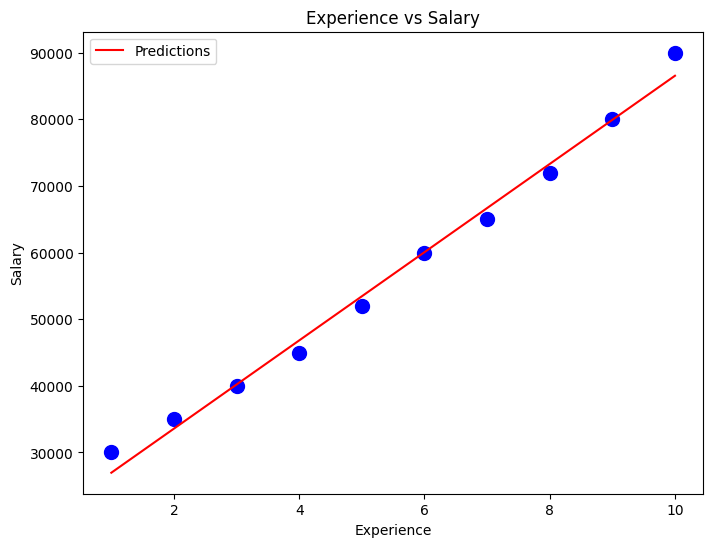

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pythondata = {'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Salary':     [30000, 35000, 40000, 45000, 52000,
                       60000, 65000, 72000, 80000, 90000]}

df=pd.DataFrame(pythondata)

print(f'\nreal dataset\n:{df}')
# I DO DIRECTLY BY RESHAPING WIHTOUT INTIALIZATION TO IND X AND Y
x_train,x_test,y_train,y_test=train_test_split(df['Experience'],df['Salary'],test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(x_train.values.reshape(-1,1),y_train)

y_pred=model.predict(x_test.values.reshape(-1,1))

print(f'\nActual values : {list(y_test)}')
print(f'\nPredicted values: \n{y_pred}')
print(f'\nSlope: {model.coef_[0]:.2f}')
print(f'\nIntercept: {model.intercept_:.2f}')

Pred=model.predict(df['Experience'].values.reshape(-1,1))
df['Predictions']=Pred
print(df)

mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f'\nMAE: {mae:.2f}')# average error in points
print(f'\nMSE: {mse:.2f}')# squared error
print(f'\n root square error : {rmse:.2f}')
print(f'\nR2 Score: {r2:.2f}')

#VISUALIZATION of PLOT & SCATTER
ax=df.plot(x='Experience',y='Salary',style='o',figsize=(8,6),kind='scatter',s=100,color='blue')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.grid(True)

df.plot(x='Experience',y='Predictions',style='-',figsize=(8,6),ax=ax,color='red')


plt.show()

